In [24]:
# Step 1: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style for the charts
sns.set_theme(style="whitegrid")

In [25]:
# Step 2: Load the Dataset
# I used skiprows=4 because World Bank files contain 4 lines of metadata at the top.
# Load data and select the 2022 column
df = pd.read_csv('API_SP.POP.TOTL_DS2_en_csv_v2_38144.csv', skiprows=4)

# Keep only the Country Name and 2022 population
data_2022 = df[['Country Name', '2022']].dropna()
data_2022.columns = ['Country', 'Population']

# Show the first 5 rows to verify it loaded
data_2022.head()

,Country,Population
0,Aruba,107310.0
1,Africa Eastern and Southern,731821393.0
2,Afghanistan,40578842.0
3,Africa Western and Central,497387180.0
4,Angola,35635029.0


In [26]:
# Step 3: Data Cleaning
# This is the most important step. We must remove all regional groups (like "World" or "High Income") so that only real countries remain.
# List of all non-country aggregates to remove
exclude_list = [
    'World', 'High income', 'OECD members', 'Post-demographic dividend',
    'IDA & IBRD total', 'Low & middle income', 'Middle income', 'IBRD only',
    'East Asia & Pacific', 'Upper middle income', 'Early-demographic dividend',
    'Lower middle income', 'Europe & Central Asia', 'South Asia', 'IBRD & IDA',
    'European Union', 'Sub-Saharan Africa', 'Arab World', 'IDA total', 
    'Africa Eastern and Southern', 'Africa Western and Central', 
    'Late-demographic dividend', 'East Asia & Pacific (excluding high income)',
    'East Asia & Pacific (IDA & IBRD countries)', 'Sub-Saharan Africa (excluding high income)',
    'Sub-Saharan Africa (IDA & IBRD countries)', 'Least developed countries: UN classification',
    'Pre-demographic dividend', 'Fragile and conflict affected situations',
    'Heavily indebted poor countries (HIPC)', 'Latin America & Caribbean',
    'Middle East & North Africa', 'South Asia (IDA & IBRD)',
    'Middle East & North Africa (excluding high income)',
    'Middle East & North Africa (IDA & IBRD countries)',
    'Latin America & Caribbean (excluding high income)',
    'Latin America & the Caribbean (IDA & IBRD countries)',
    'Europe & Central Asia (excluding high income)',
    'Europe & Central Asia (IDA & IBRD countries)',
    'Middle East, North Africa, Afghanistan & Pakistan (IDA & IBRD)',
    'Middle East, North Africa, Afghanistan & Pakistan (excluding high income)',
    'Middle East, North Africa, Afghanistan & Pakistan',
    'North America', 'Euro area', 'IDA only', 'IDA blend', 'Low income',
    'Small states', 'Other small states', 'Pacific island small states', 
    'Caribbean small states', 'Central Europe and the Baltics'
]

# Apply the filter
df_final = data_2022[~data_2022['Country'].isin(exclude_list)]
df_final = df_final.sort_values(by='Population', ascending=False)

print(f"Total individual countries identified: {len(df_final)}")

Total individual countries identified: 217


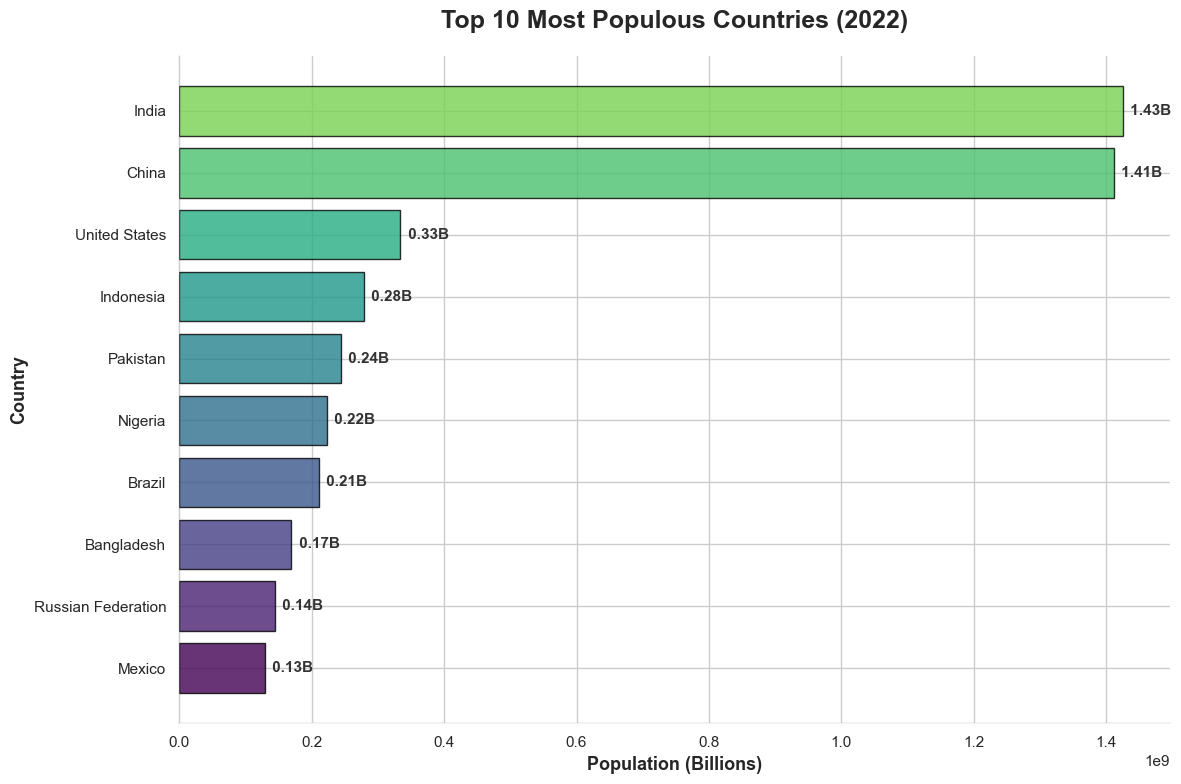

<Figure size 640x480 with 0 Axes>

In [40]:
# Step 5: Create the Bar chart (Continuous Variable)
# Get Top 10 and reverse for horizontal display (Top at the top)
top_10 = df_final.head(10).iloc[::-1] 

# 2. Setup Figure and Colors
plt.figure(figsize=(12, 8))

# We use a colormap ('viridis', 'plasma', or 'Spectral') to give each bar a unique color
colors = plt.cm.viridis(np.linspace(0, 0.8, len(top_10)))

# 3. Create Horizontal Bar Chart
# Note: Country names are Categorical, Population is the value
bars = plt.barh(top_10['Country'], top_10['Population'], color=colors, edgecolor='black', alpha=0.8)

# 4. Beautiful Styling
plt.title('Top 10 Most Populous Countries (2022)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Population (Billions)', fontsize=13, fontweight='bold')
plt.ylabel('Country', fontsize=13, fontweight='bold')
plt.grid(True)

# Remove top and right borders (spines) for a clean "flat" design
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_alpha(0.3)
plt.gca().spines['left'].set_alpha(0.3)

# 5. Add Value Labels at the end of the bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 5000000, # Small padding from the end of the bar
             bar.get_y() + bar.get_height()/2, 
             f' {width/1e9:.2f}B', 
             va='center', fontweight='bold', fontsize=11, color='#333333')

plt.tight_layout()
plt.show()
plt.savefig('population_bar_chart.png')

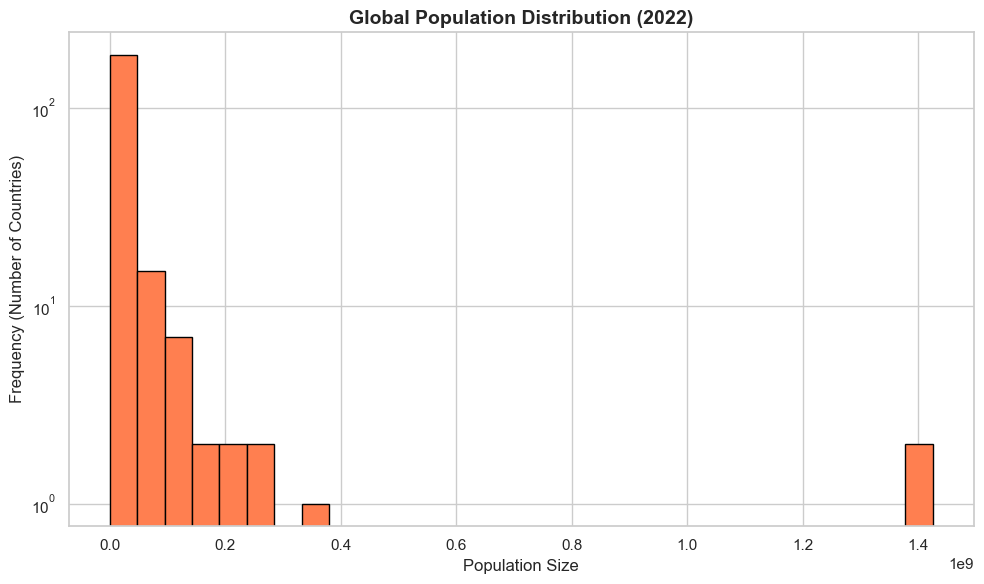

<Figure size 640x480 with 0 Axes>

In [41]:
# Step 5: Create the Histogram (Continuous Variable)
# Use this to see the frequency distribution across all countries.
plt.figure(figsize=(10, 6))
plt.hist(df_final['Population'], bins=30, color='coral', edgecolor='black')

plt.title('Global Population Distribution (2022)', fontsize=14, fontweight='bold')
plt.xlabel('Population Size', fontsize=12)
plt.ylabel('Frequency (Number of Countries)', fontsize=12)

# Log scale is used because India/China are outliers compared to small nations
plt.yscale('log') 

plt.tight_layout()
plt.show()
plt.savefig('population_histogram.png')

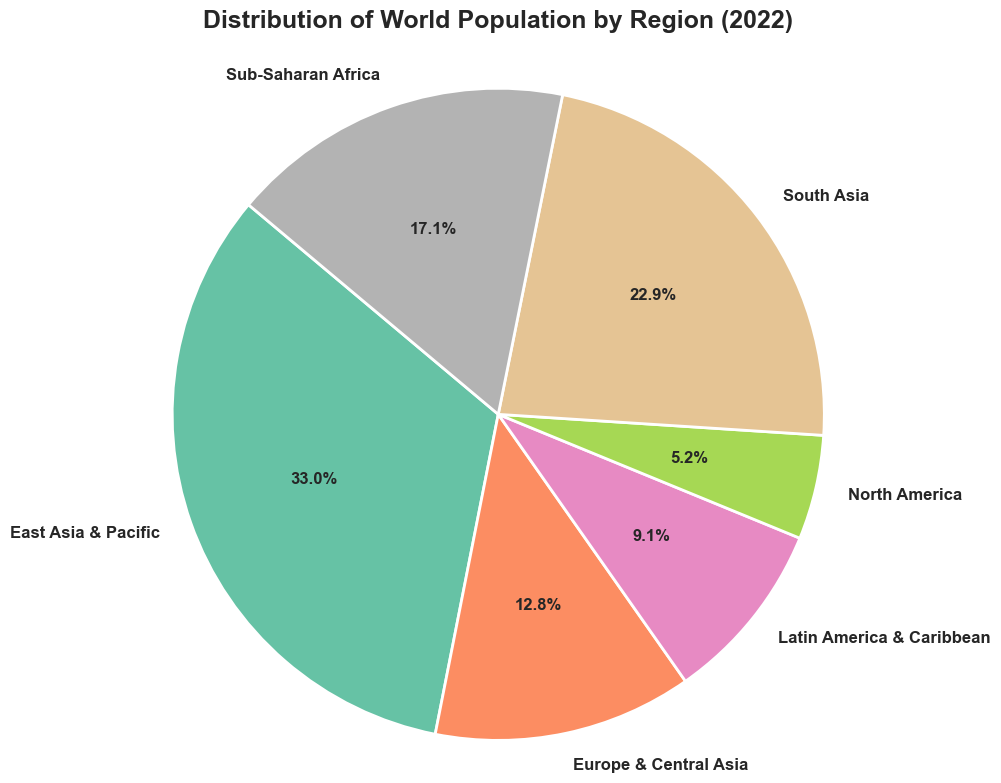

<Figure size 640x480 with 0 Axes>

In [42]:
# 1. Define the specific regions 
# (Ensuring these match the World Bank naming exactly)
regions_list = [
    'South Asia', 
    'Europe & Central Asia', 
    'East Asia & Pacific', 
    'Sub-Saharan Africa', 
    'Latin America & Caribbean', 
    'North America'
]

# 2. Filter data for these regions for 2022
df_pie = df[df['Country Name'].isin(regions_list)][['Country Name', '2022']]
df_pie.columns = ['Region', 'Population']

# 3. Setup the Figure
plt.figure(figsize=(10, 8))

# 4. Use a professional color palette
colors = plt.cm.Set2(np.linspace(0, 1, len(df_pie)))

# 5. Create the Pie Chart
# Note: 'edgecolor' is moved inside 'wedgeprops'
plt.pie(df_pie['Population'], 
        labels=df_pie['Region'], 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colors, 
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}, # Corrected line
        textprops={'fontsize': 12, 'fontweight': 'bold'})

# 6. Final Styling
plt.title('Distribution of World Population by Region (2022)', fontsize=18, fontweight='bold', pad=20)
plt.axis('equal') 

plt.tight_layout()
plt.show()
plt.savefig('population_pie_chart.png')